# Simple Linear Regression

In this notebook, I will build a simple linear regression model.

The model will learn the relationship between study hours and exam scores.

## Workflow

1. Prepare the dataset
2. Separate feature and target
3. Split the data into train and test sets
4. Train the model
5. Make predictions
6. Evaluate the model using MSE and RMSE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Exam_Score": [42, 48, 55, 61, 66, 72, 78, 84, 89, 95]
}

df = pd.DataFrame(data)

df

,Study_Hours,Exam_Score
0,1,42
1,2,48
2,3,55
3,4,61
4,5,66
5,6,72
6,7,78
7,8,84
8,9,89
9,10,95


## Dataset

The dataset contains study hours and exam scores.

- `Study_Hours` is the feature.
- `Exam_Score` is the target.
- Each row represents one student.

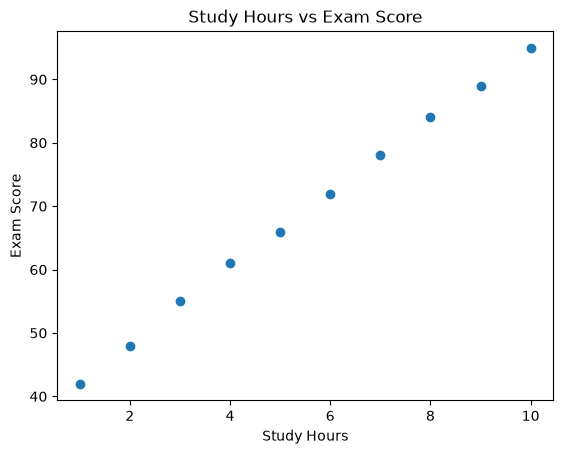

In [3]:
plt.scatter(df["Study_Hours"], df["Exam_Score"])

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")

plt.show()

## My Notes

The scatter plot shows a positive relationship between study hours and exam scores.

As study hours increase, exam scores generally increase too.

In [4]:
X = df[["Study_Hours"]]
y = df["Exam_Score"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (10, 1)
Target shape: (10,)


## My Notes

`X` contains the input feature.

`y` contains the target values.

The model will use study hours to predict exam scores.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 8
Test samples: 2


## Train and Test Split

The training set is used to teach the model.

The test set is used to evaluate the model on unseen data.

In this example, 80% of the data is used for training and 20% is used for testing.

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [7]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 5.85344827586207
Intercept: 36.93103448275861


## My Notes

The coefficient shows how much the predicted exam score changes when study hours increase by one unit.

The intercept is the predicted starting value when the feature is zero.

In [8]:
predictions = model.predict(X_test)

results = pd.DataFrame({
    "Study_Hours": X_test["Study_Hours"].values,
    "Actual_Score": y_test.values,
    "Predicted_Score": predictions
})

results

,Study_Hours,Actual_Score,Predicted_Score
0,9,89,89.612069
1,2,48,48.637931


In [9]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 0.3907922116527899
RMSE: 0.6251337550099098


## Model Evaluation

MSE and RMSE measure the difference between actual values and predicted values.

A lower value usually means that the predictions are closer to the real results.

RMSE is easier to interpret because it uses the same unit as the exam score.

In [10]:
new_data = pd.DataFrame({
    "Study_Hours": [6.5]
})

predicted_score = model.predict(new_data)

print("Predicted score for 6.5 study hours:", predicted_score[0])

Predicted score for 6.5 study hours: 74.97844827586206


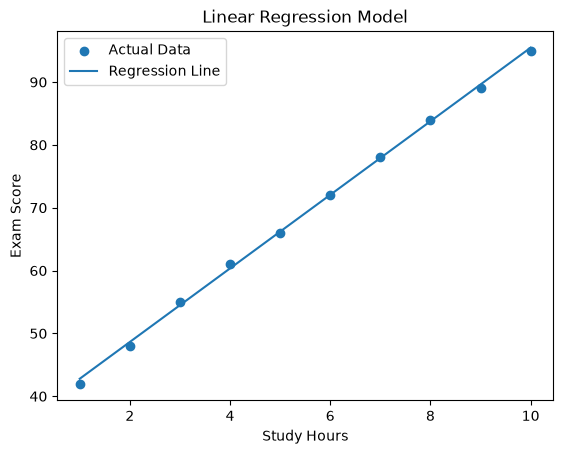

In [11]:
all_predictions = model.predict(X)

plt.scatter(X, y, label="Actual Data")
plt.plot(X, all_predictions, label="Regression Line")

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Linear Regression Model")
plt.legend()

plt.show()

## What I Learned

In this notebook, I built my first machine learning model using linear regression.

I separated the feature and target, divided the data into train and test sets, trained the model, and made predictions.

I evaluated the model using MSE and RMSE.

I also learned that a trained model can make predictions for new input values.

This workflow is similar to the workflow I will use in the stock price prediction project, although the final project will use time-series data and deep learning models.